In [1]:
import pandas as pd
import random

random.seed(42)

data = []

for i in range(300):

    package_weight = random.randint(1, 20)
    package_size = random.randint(1, 5)
    fragility_level = random.randint(1, 5)
    distance = random.randint(5, 2000)
    handling_points = random.randint(1, 10)
    packaging_quality = random.randint(1, 5)
    weather_risk = random.randint(0, 1)

    risk_score = (
        fragility_level
        + handling_points
        + weather_risk
        + (distance / 500)
        - packaging_quality
    )

    if risk_score >= 8:
        damage_risk = "High Damage Risk"

    elif risk_score >= 5:
        damage_risk = "Medium Damage Risk"

    else:
        damage_risk = "Low Damage Risk"

    data.append([
        package_weight,
        package_size,
        fragility_level,
        distance,
        handling_points,
        packaging_quality,
        weather_risk,
        damage_risk
    ])

df = pd.DataFrame(data, columns=[
    "package_weight",
    "package_size",
    "fragility_level",
    "distance",
    "handling_points",
    "packaging_quality",
    "weather_risk",
    "damage_risk"
])

df.head()

,package_weight,package_size,fragility_level,distance,handling_points,packaging_quality,weather_risk,damage_risk
0,4,1,3,506,4,2,0,Medium Damage Risk
1,18,1,5,869,1,1,0,Medium Damage Risk
2,7,2,5,1237,1,5,0,Low Damage Risk
3,18,4,2,924,10,3,0,High Damage Risk
4,6,4,3,574,3,2,1,Medium Damage Risk


In [6]:
df.shape
X = df.drop("damage_risk", axis=1)
y = df["damage_risk"]
X.head()
y.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print(prediction)

(240, 7)
(60, 7)
['High Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'Medium Damage Risk' 'Medium Damage Risk'
 'High Damage Risk' 'Medium Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'Low Damage Risk' 'High Damage Risk' 'Medium Damage Risk'
 'High Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'Medium Damage Risk' 'High Damage Risk' 'Low Damage Risk'
 'High Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'High Damage Risk' 'Medium Damage Risk'
 'High Damage Risk' 'Low Damage Risk' 'Medium Damage Risk'
 'Medium Damage Risk' 'Medium Damage Risk' 'High Damage Risk'
 'Medium Damage Risk' 'High Damage Risk' 'High Damage Risk'
 'Medium Damage Risk' 'High Damage Risk' 'Low Damage Risk'
 'High Damage Risk' 'Low Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'Medium Damage Risk' 'High Damage Risk'
 'High Damage Risk' 'High Damage Ris

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": prediction
})

comparison

Accuracy: 0.8333333333333334


,Actual,Prediction
0,Medium Damage Risk,High Damage Risk
1,High Damage Risk,High Damage Risk
2,Medium Damage Risk,High Damage Risk
3,High Damage Risk,High Damage Risk
4,Medium Damage Risk,Medium Damage Risk
5,High Damage Risk,Medium Damage Risk
6,High Damage Risk,High Damage Risk
7,Medium Damage Risk,Medium Damage Risk
8,High Damage Risk,High Damage Risk
9,High Damage Risk,High Damage Risk


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

                    precision    recall  f1-score   support

  High Damage Risk       0.87      0.94      0.90        35
   Low Damage Risk       0.83      0.71      0.77         7
Medium Damage Risk       0.75      0.67      0.71        18

          accuracy                           0.83        60
         macro avg       0.82      0.77      0.79        60
      weighted avg       0.83      0.83      0.83        60



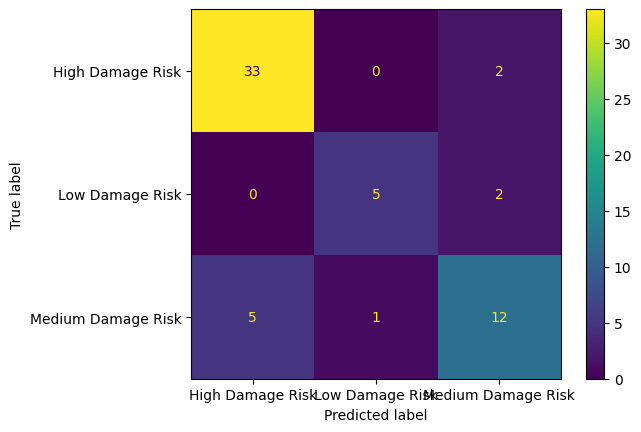

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()

In [11]:
new_package = pd.DataFrame([{
    "package_weight": 10,
    "package_size": 4,
    "fragility_level": 5,
    "distance": 1200,
    "handling_points": 8,
    "packaging_quality": 2,
    "weather_risk": 1
}])

new_prediction = model.predict(new_package)

print("Damage Risk:", new_prediction[0])

Damage Risk: High Damage Risk


In [12]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
4,handling_points,0.358101
3,distance,0.164441
2,fragility_level,0.158163
5,packaging_quality,0.111568
0,package_weight,0.109671
1,package_size,0.063664
6,weather_risk,0.034390


In [13]:
import joblib

joblib.dump(model, "package_damage_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [14]:
def predict_damage(
    package_weight,
    package_size,
    fragility_level,
    distance,
    handling_points,
    packaging_quality,
    weather_risk
):
    new_package = pd.DataFrame([{
        "package_weight": package_weight,
        "package_size": package_size,
        "fragility_level": fragility_level,
        "distance": distance,
        "handling_points": handling_points,
        "packaging_quality": packaging_quality,
        "weather_risk": weather_risk
    }])

    prediction = model.predict(new_package)

    return prediction[0]

In [16]:
!pip install gradio
import gradio as gr

interface = gr.Interface(
    fn=predict_damage,
    inputs=[
        gr.Number(label="Package Weight (kg)"),
        gr.Number(label="Package Size (1-5)"),
        gr.Number(label="Fragility Level (1-5)"),
        gr.Number(label="Delivery Distance (km)"),
        gr.Number(label="Handling Points (1-10)"),
        gr.Number(label="Packaging Quality (1-5)"),
        gr.Number(label="Weather Risk (0 = No, 1 = Yes)")
    ],
    outputs=gr.Textbox(label="Damage Risk"),
    title="Package Damage Risk Predictor",
    description="Predict the potential damage risk of a package before dispatch."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5bd527dd1c3789aa8c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
